In [29]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\arekr\OneDrive\Pulpit\Semestr6\SSNE\ssne_26L\venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\arekr\OneDrive\Pulpit\Semestr6\SSNE\ssne_26L\venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line

In [28]:
import os
import json
import math
import numpy as np
import pandas as pd

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
# from IPython.display import set_matplotlib_formats
from matplotlib.colors import to_rgb
import matplotlib
# matplotlib.rcParams['lines.linewidth'] = 2.0
# import seaborn as sns

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
# Torchvision
import torchvision
from torchvision.datasets import FashionMNIST
from torchvision import transforms

from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import random_split

from modele import *

In [18]:
device = torch.device("cuda:2") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cpu


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.3184, 0.2927, 0.3013), (0.2763, 0.2655, 0.2686)),
])

dataset = ImageFolder("trafic_32", transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [20]:
for images, labels in train_loader:
    print(images.shape)  # [batch_size, 3, 32, 32]
    print(labels.shape)  # [batch_size]
    break

torch.Size([32, 3, 32, 32])
torch.Size([32])


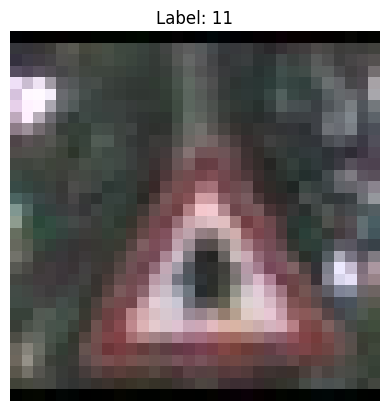

00011


In [ ]:
image, label = train_dataset[100]

# PyTorch tensor → HWC for plotting
img = image.permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [ ]:
# all_samples = torch.stack([sample[0] for sample in train_dataset])
# print(f"Data norm: mean={all_samples.mean():.4f} | std={all_samples.std():.4f}")
# print(f"Data norm per channel: mean={all_samples.mean(axis=(0,2,3))} | std={all_samples.std(axis=(0,2,3))}")

# Data norm: mean=0.3041 | std=0.2704
# Data norm per channel: mean=tensor([0.3184, 0.2927, 0.3013]) | std=tensor([0.2763, 0.2655, 0.2686])

Data norm: mean=0.3041 | std=0.2704
Data norm per channel: mean=tensor([0.3184, 0.2927, 0.3013]) | std=tensor([0.2763, 0.2655, 0.2686])


In [24]:
def corrupt(x, amount):
    """Corrupt the input `x` by mixing it with noise according to `amount`"""
    noise = torch.rand_like(x)
    amount = amount.view(-1, 1, 1, 1) # Sort shape so broadcasting works
    return x*(1-amount) + noise*amount

Input shape: torch.Size([8, 3, 32, 32])


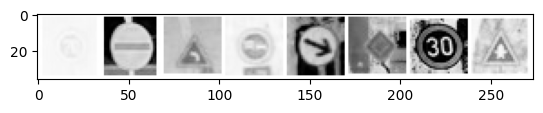

In [25]:
x, y = next(iter(train_loader))
x = x[:8]
print('Input shape:', x.shape)
plt.imshow(torchvision.utils.make_grid(x)[0], cmap='Greys');

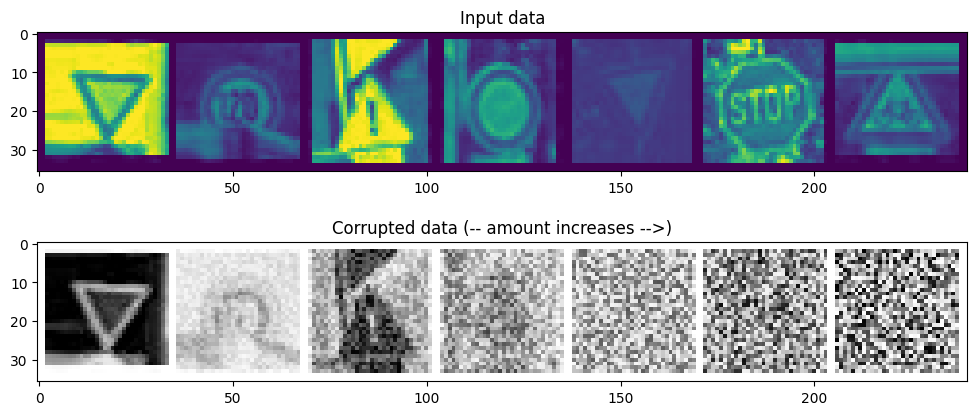

In [33]:
# Plotting the input data
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(x)[0])

# Adding noise
amount = torch.linspace(0, 1, x.shape[0]) # Left to right -> more corruption
noised_x = corrupt(x, amount)

# Plotting the noised version
axs[1].set_title('Corrupted data (-- amount increases -->)')
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0], cmap='Greys');

In [ ]:
net = BasicUNet().to(device)
net

BasicUNet(
  (down_layers): ModuleList(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (up_layers): ModuleList(
    (0): Conv2d(65, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (act): SiLU()
  (downscale): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (upscale): Upsample(scale_factor=2.0, mode='nearest')
)

c:\Users\arekr\OneDrive\Pulpit\Semestr6\SSNE\ssne_26L\venv\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([32, 3, 32, 32])) that is different to the input size (torch.Size([32, 1, 32, 32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\arekr\OneDrive\Pulpit\Semestr6\SSNE\ssne_26L\venv\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([7, 3, 32, 32])) that is different to the input size (torch.Size([7, 1, 32, 32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Finished epoch 0. Average loss for this epoch: 0.022764
Finished epoch 1. Average loss for this epoch: 0.017789
Finished epoch 2. Average loss for this epoch: 0.015948
Finished epoch 3. Average loss for this epoch: 0.015528
Finished epoch 4. Average loss for this epoch: 0.014774


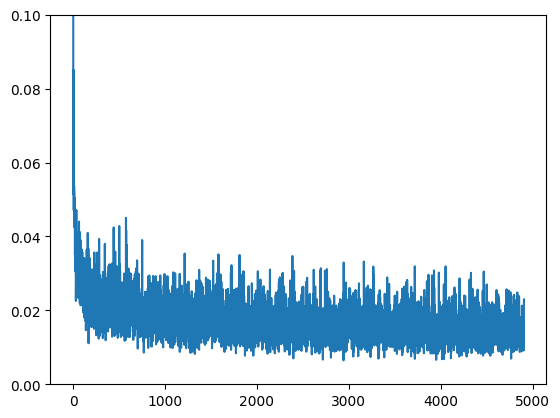

In [32]:
n_epochs = 5

# Create the network
net = BasicUNet(in_channels=3)
net.to(device)

# Funkcja straty - zwykłe MSE
loss_fn = nn.MSELoss()

# Optymalizator
opt = torch.optim.Adam(net.parameters(), lr=1e-3)

# Wartości funkcji straty
losses = []

# The training loop
for epoch in range(n_epochs):

    for x, y in train_loader:

        # Przygotowanie danych
        x = x.to(device)
        # Losowanie ilości dodanego szumu - może być krok, albo jak w tym przypadku ciągła wartość w %
        noise_amount = torch.rand(x.shape[0]).to(device)
        noisy_x = corrupt(x, noise_amount) # Zaszumiony przykład

        # Predykcja oryginalnego - czystego obrazka
        pred = net(noisy_x, noise_amount)

        # Porównanie z oryginalnym obrazkiem
        loss = loss_fn(pred, x) #

        opt.zero_grad()
        loss.backward()
        opt.step()

        losses.append(loss.item())

    # Średni loss per epoka:
    avg_loss = sum(losses[-len(train_loader):])/len(train_loader)
    print(f'Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}')

# View the loss curve
plt.plot(losses)
plt.ylim(0, 0.1);

(np.float64(-0.5), np.float64(273.5), np.float64(273.5), np.float64(-0.5))

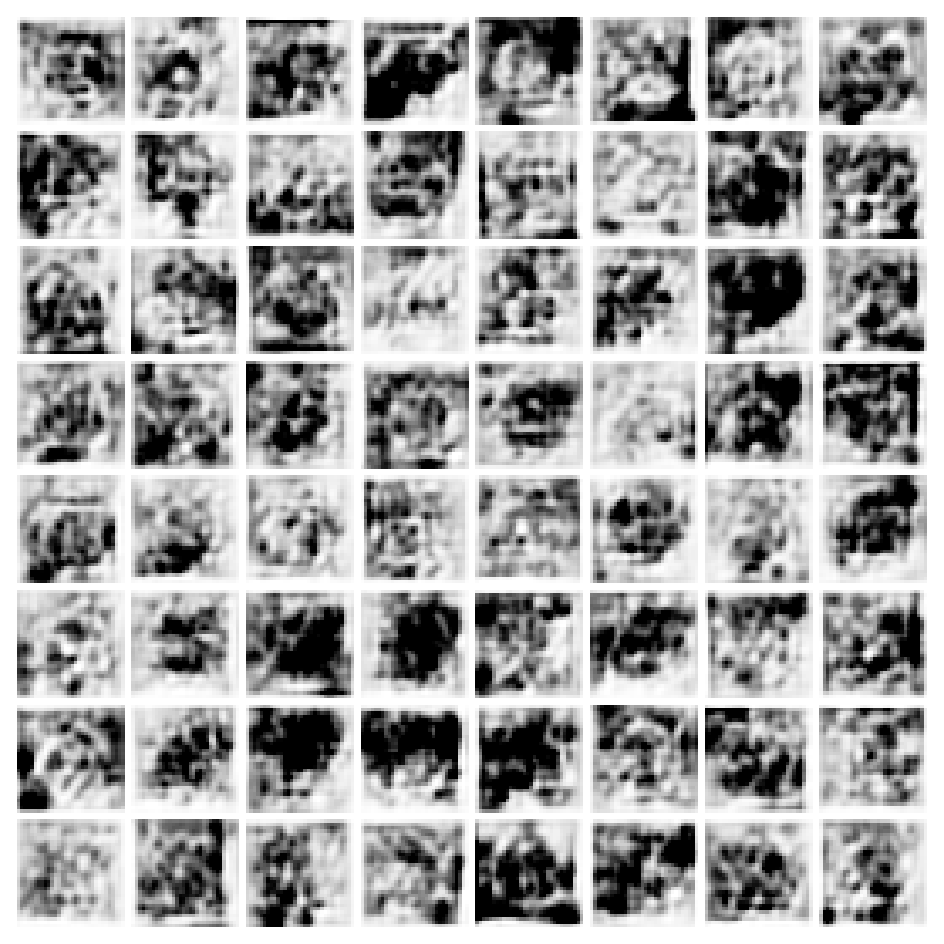

In [35]:
n_steps = 40
x = torch.rand(64, 3, 32, 32).to(device)
for i in range(n_steps):
  t = (torch.zeros(x.size(0)) + (n_steps - i)/n_steps).to(device)
  noise_amount = torch.ones((x.shape[0], )).to(device) * (1-(i/n_steps)) # Starting high going low
  with torch.no_grad():
    pred = net(x, t)
#-----------Samplowanie
    mix_factor = 1/(n_steps - i)
    x = x*(1-mix_factor) + pred*mix_factor
#----------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
ax.imshow(torchvision.utils.make_grid(x.detach().cpu(), nrow=8)[0].clip(0, 1), cmap='Greys')
ax.axis('off')